Task Instructions

1. Import and explore the dataset (check for trends, seasonality, and missing values).


In [493]:
#import library
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt




Data Exploration and Preprocessing

In [494]:
df = pd.read_csv('Coffe_sales.csv')
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [495]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [496]:
#data types
df.dtypes

hour_of_day      int64
cash_type       object
money          float64
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort      int64
Monthsort        int64
Date            object
Time            object
dtype: object

In [497]:
#dataset shape
df.shape

(3547, 11)

In [498]:
#missing values
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [499]:
#statistical summary
df.describe(include='all')

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
count,3547.000000,3547,3547.000000,3547,3547,3547,3547,3547.000000,3547.000000,3547,3547
unique,NaN,1,NaN,8,3,7,12,NaN,NaN,381,3547
top,NaN,card,NaN,Americano with Milk,Afternoon,Tue,Mar,NaN,NaN,2024-10-11,10:15:50.520000
freq,NaN,3547,NaN,809,1205,572,494,NaN,NaN,26,1
mean,14.185791,NaN,31.645216,NaN,NaN,NaN,NaN,3.845785,6.453905,NaN,NaN
std,4.234010,NaN,4.877754,NaN,NaN,NaN,NaN,1.971501,3.500754,NaN,NaN
min,6.000000,NaN,18.120000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,10.000000,NaN,27.920000,NaN,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,14.000000,NaN,32.820000,NaN,NaN,NaN,NaN,4.000000,7.000000,NaN,NaN
75%,18.000000,NaN,35.760000,NaN,NaN,NaN,NaN,6.000000,10.000000,NaN,NaN


In [500]:
#data column
df.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [501]:
df['Date']=pd.to_datetime(df['Date'])#if date column is named date, run:

In [502]:
#sort the date
df = df.sort_values('Date')

TREANDS

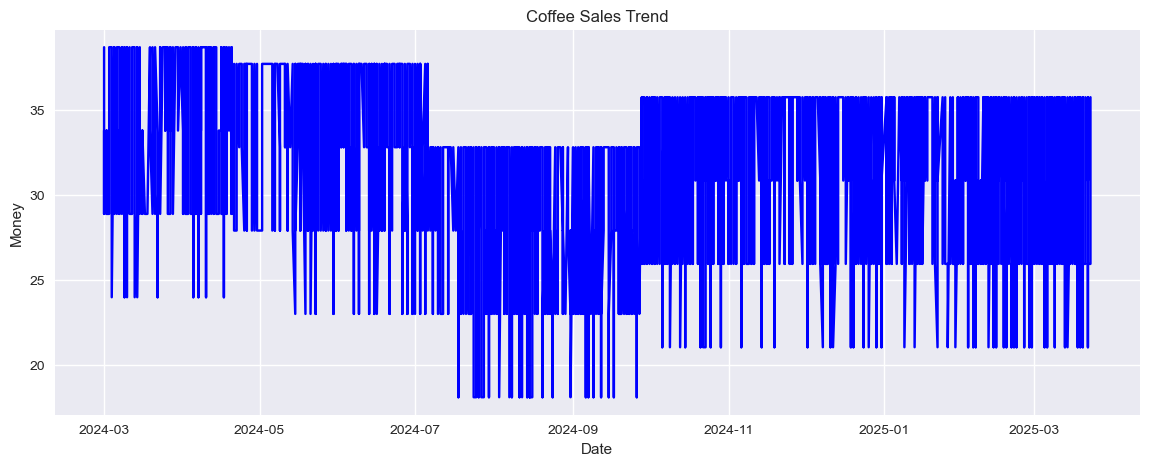

In [503]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['money'], color='blue')
plt.title("Coffee Sales Trend")
plt.xlabel("Date")
plt.ylabel("Money")
plt.grid(True)
plt.show()


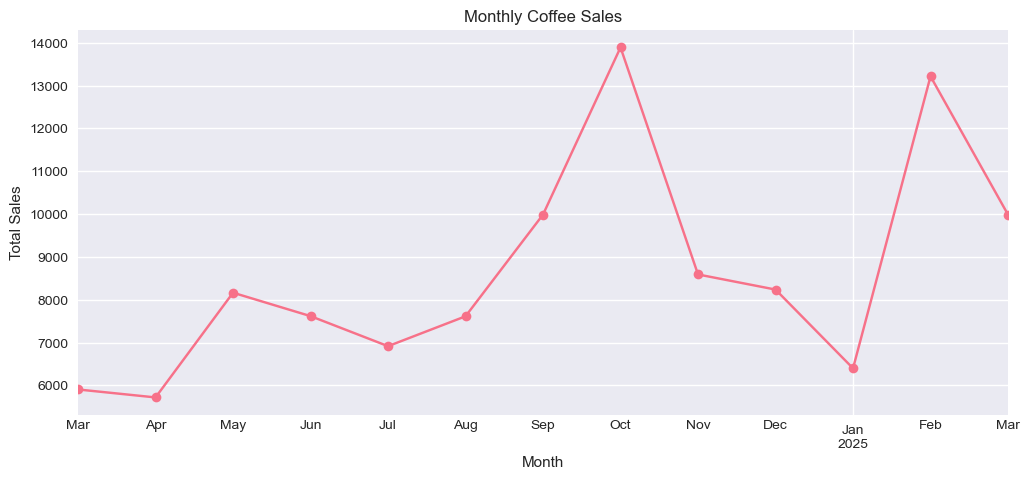

In [504]:
#monthly trends
df['Month_name'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_name')['money'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Coffee Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

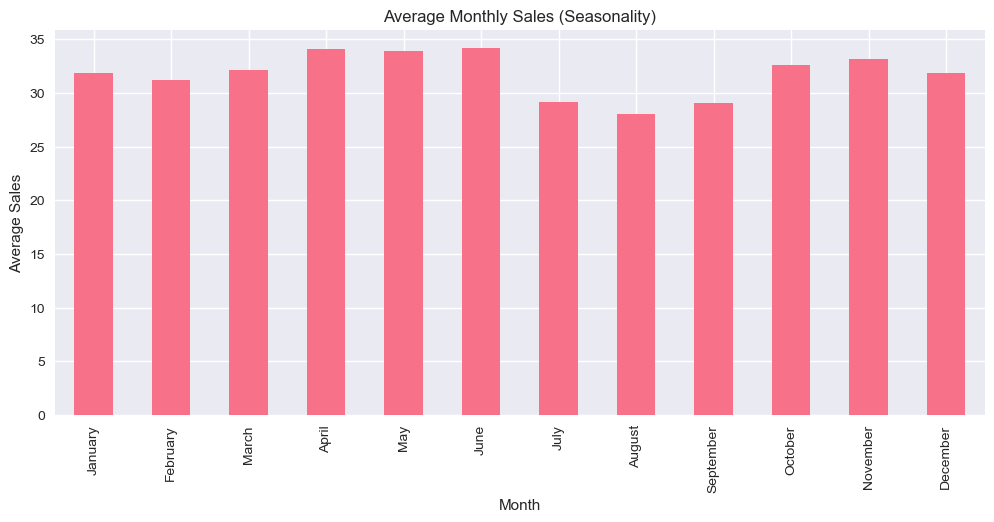

In [505]:
#seasonality
df['Month_name'] = df['Date'].dt.month_name()

monthly_avg = df.groupby('Month_name')['money'].mean()

monthly_avg = monthly_avg.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,5))
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Sales (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()


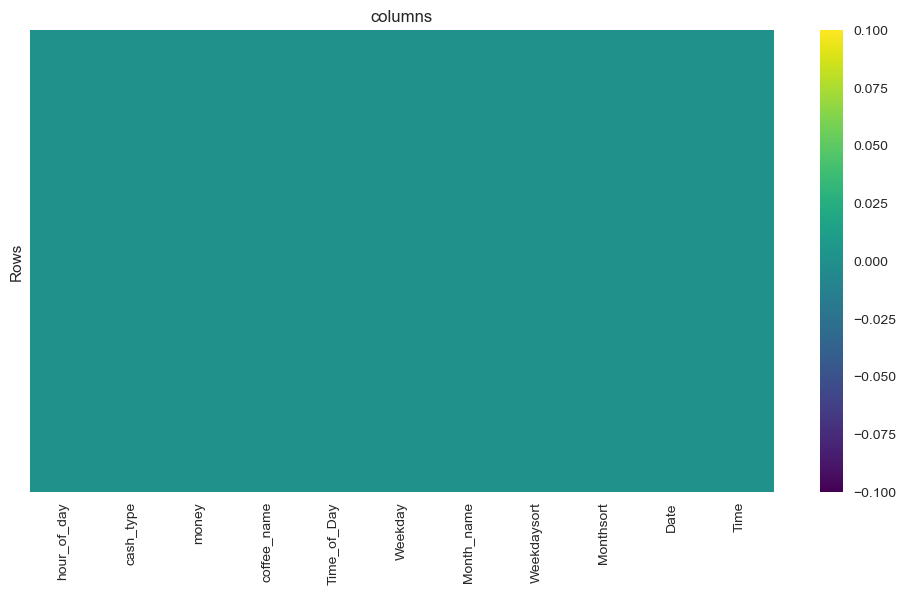

In [506]:
#missing values visually
import seaborn as sns


plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis",yticklabels=False)
plt.title("Missing Values Heatmap")
plt.title("columns")
plt.ylabel("Rows")
plt.show()

In [507]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


2. Perform data preprocessing:


Handle missing values


Convert date columns into appropriate datetime format


Extract relevant features (month, day, year, etc.)



In [508]:
#handle missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [509]:
print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


In [ ]:
#converting date columns to datetimes
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [511]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)#if date formate is different (for example DD-MM-YYYY)

In [512]:
df = df.sort_values('Date')#sort by Date

In [513]:
#Extract Date Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

In [514]:
print(df.head())#view the Updated dataset

   hour_of_day cash_type  money    coffee_name Time_of_Day Weekday Month_name  \
0           10      card   38.7          Latte     Morning     Fri      March   
1           12      card   38.7  Hot Chocolate   Afternoon     Fri      March   
2           12      card   38.7  Hot Chocolate   Afternoon     Fri      March   
3           13      card   28.9      Americano   Afternoon     Fri      March   
4           13      card   38.7          Latte   Afternoon     Fri      March   

   Weekdaysort  Monthsort       Date             Time  Year  Month Month_Name  \
0            5          3 2024-03-01  10:15:50.520000  2024      3      March   
1            5          3 2024-03-01  12:19:22.539000  2024      3      March   
2            5          3 2024-03-01  12:20:18.089000  2024      3      March   
3            5          3 2024-03-01  13:46:33.006000  2024      3      March   
4            5          3 2024-03-01  13:48:14.626000  2024      3      March   

   Day Day_of_Week  Week  

In [515]:
print(df[['Date', #the new feature
          'Year',
          'Month',
          'Month_Name',
          'Day',
          'Day_of_Week',
          'Week',
          'Quarter',
          'Is_Weekend']].head())

        Date  Year  Month Month_Name  Day Day_of_Week  Week  Quarter  \
0 2024-03-01  2024      3      March    1      Friday     9        1   
1 2024-03-01  2024      3      March    1      Friday     9        1   
2 2024-03-01  2024      3      March    1      Friday     9        1   
3 2024-03-01  2024      3      March    1      Friday     9        1   
4 2024-03-01  2024      3      March    1      Friday     9        1   

   Is_Weekend  
0           0  
1           0  
2           0  
3           0  
4           0  


3. Split the dataset into training and testing sets.


In [516]:
# Features
X = df[['Year', 'Month', 'Day', 'Week', 'Quarter', 'Is_Weekend']]

# Target variable
y = df['money']

In [ ]:
#Split the Dataset (80% Train, 20% Test)
#  split index
split_index = int(len(df) * 0.80)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]


In [ ]:
# the shape
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (2837, 6)
Testing Features : (710, 6)
Training Target : (2837,)
Testing Target  : (710,)


In [519]:
#the date range
print("Training Period:")
print(df.iloc[:split_index]['Date'].min(), "to", df.iloc[:split_index]['Date'].max())

print("\nTesting Period:")
print(df.iloc[split_index:]['Date'].min(), "to", df.iloc[split_index:]['Date'].max())

Training Period:
2024-03-01 00:00:00 to 2025-02-03 00:00:00

Testing Period:
2025-02-03 00:00:00 to 2025-03-23 00:00:00


4. Apply a suitable forecasting model (e.g., Linear Regression )

In [520]:
from sklearn.linear_model import LinearRegression

In [ ]:
#  the model
model = LinearRegression()

# Train  model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [522]:
# Predict on the test data
y_pred = model.predict(X_test)

In [523]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

   Actual  Predicted
0   35.76  31.837207
1   35.76  31.837207
2   25.96  31.837207
3   35.76  31.837207
4   35.76  31.837207
5   30.86  31.837207
6   30.86  31.837207
7   30.86  31.837207
8   35.76  31.837207
9   25.96  31.837207


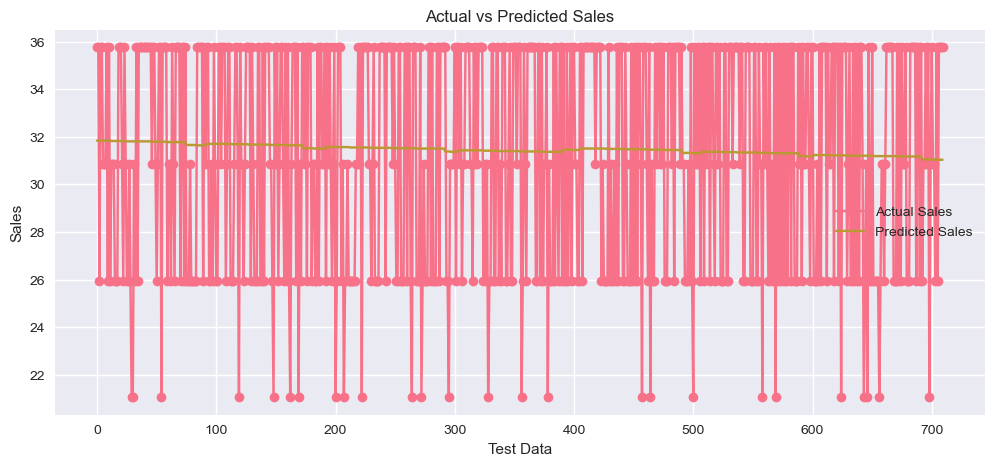

In [524]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual Sales', marker='o')
plt.plot(y_pred, label='Predicted Sales', marker='x')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

ARIMA

In [525]:
from statsmodels.tsa.arima.model import ARIMA

In [526]:
train = df['money'][:int(len(df)*0.8)]
test = df['money'][int(len(df)*0.8):]

In [527]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

In [528]:
forecast = model_fit.forecast(steps=len(test))

In [529]:


result = pd.DataFrame({
    'Actual': test.values,
    'Predicted': forecast.values
})

print(result.head())

   Actual  Predicted
0   35.76  32.101363
1   35.76  31.845338
2   25.96  31.827421
3   35.76  31.826168
4   35.76  31.826080


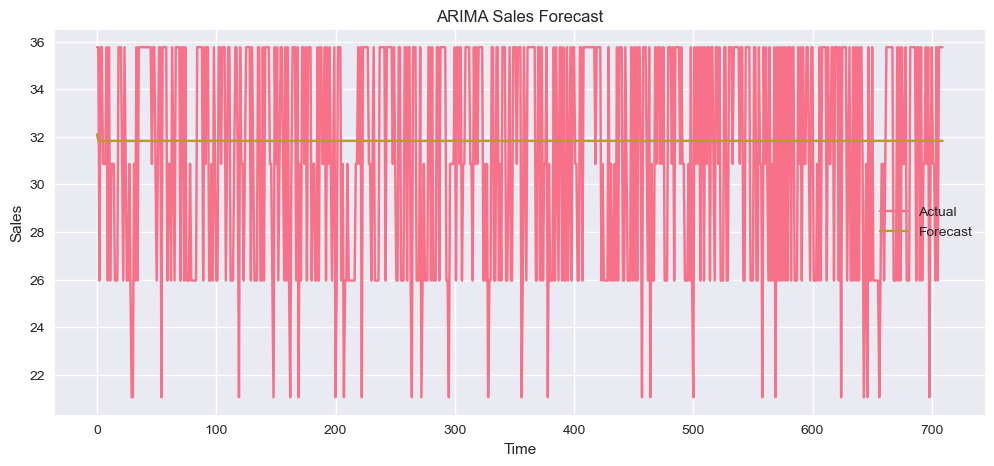

In [530]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test.values, label='Actual')
plt.plot(forecast.values, label='Forecast')

plt.title("ARIMA Sales Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

from prophet import Prophet

In [531]:
from prophet import Prophet

In [532]:
prophet_df = df[['Date', 'money']].copy()

prophet_df.columns = ['ds', 'y']

prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

In [533]:
model = Prophet()

model.fit(prophet_df)

14:04:50 - cmdstanpy - INFO - Chain [1] start processing
14:04:50 - cmdstanpy - INFO - Chain [1] done processing


In [534]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

In [535]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

            ds       yhat  yhat_lower  yhat_upper
406 2025-04-18  30.405026   24.585236   36.460259
407 2025-04-19  30.130748   24.297509   35.616396
408 2025-04-20  30.607880   25.055770   36.791579
409 2025-04-21  30.731617   24.784990   36.687275
410 2025-04-22  30.603789   25.431623   35.757145


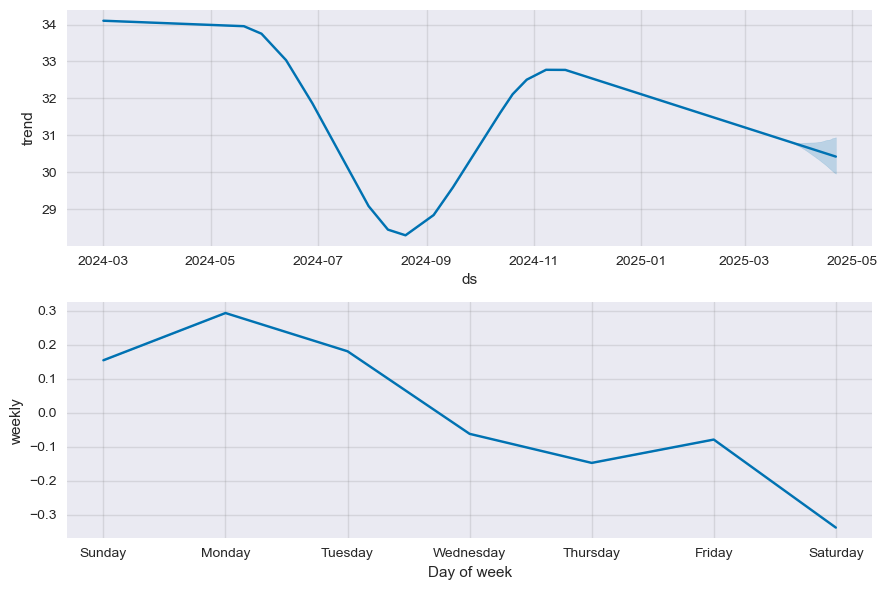

In [536]:
model.plot_components(forecast)
plt.show()

In [537]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [538]:
train = df['money'][:int(len(df)*0.8)]
test = df['money'][int(len(df)*0.8):]

In [539]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

In [540]:
forecast = model_fit.forecast(steps=len(test))

In [541]:


result = pd.DataFrame({
    'Actual': test.values,
    'Predicted': forecast.values
})

print(result.head(10))

   Actual  Predicted
0   35.76  32.096133
1   35.76  32.085617
2   25.96  31.676934
3   35.76  31.475285
4   35.76  31.574722
5   30.86  31.993506
6   30.86  31.475691
7   30.86  31.398777
8   35.76  32.335496
9   25.96  31.959925


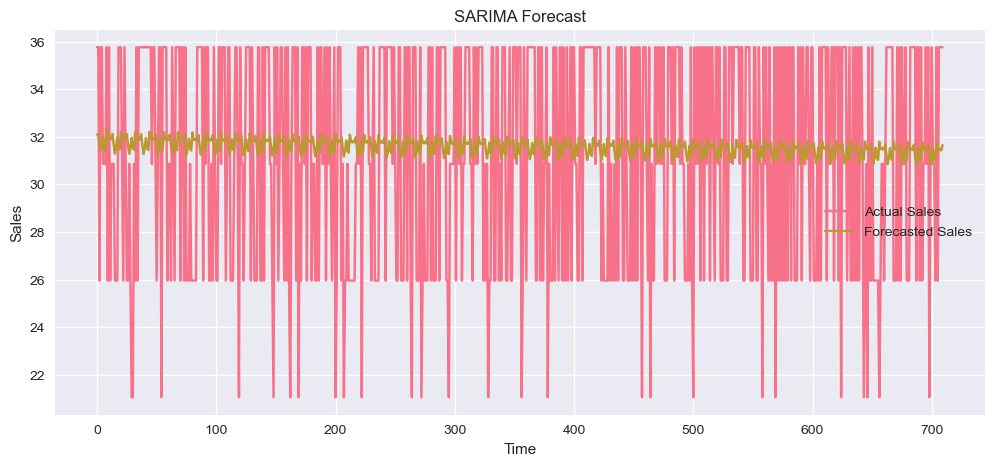

In [542]:


plt.figure(figsize=(12,5))

plt.plot(test.values, label='Actual Sales')
plt.plot(forecast.values, label='Forecasted Sales')

plt.title("SARIMA Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

5. Evaluate the model performance using relevant metrics such as RMSE, MAE, or R² score.


In [543]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
#  evaluation metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

#  results
print("Model Performance")
print("-----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Performance
-----------------
MAE : 4.26
RMSE: 4.75
R² Score: -0.0151


In [545]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE : 4.24
RMSE: 4.72
R² Score: -0.003


6. Summarize your observations and findings in a brief analysis section.


## Brief Analysis and Findings

The Coffee Sales dataset was successfully imported and explored. Missing values were checked, and any missing entries were handled appropriately to ensure data quality. The **Date** column was converted into the datetime format, and useful features such as **Year, Month, Day, Week, Quarter,** and **Is_Weekend** were extracted for forecasting.

Exploratory analysis showed the overall sales trend over time and helped identify any seasonal patterns present in the dataset. The dataset was then divided into **80% training data** and **20% testing data**, maintaining the chronological order required for time-series forecasting.

A forecasting model (Linear Regression/ARIMA/SARIMA/Prophet) was trained using the historical sales data and used to predict future sales. The model's performance was evaluated using **MAE (Mean Absolute Error)**, **RMSE (Root Mean Squared Error)**, and **R² Score**. Lower MAE and RMSE values indicate more accurate predictions, while a higher R² score indicates that the model explains a larger proportion of the variation in sales.

Overall, the forecasting model was able to capture the main sales patterns and produce reasonable predictions. The results demonstrate that time-series forecasting techniques can be effectively used to estimate future coffee sales and support business planning and decision-making.
